# 道路


数据集信息:
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 47403 entries, 0 to 47402
Columns: 104 entries, full_id to geometry
dtypes: geometry(1), object(103)
memory usage: 37.6+ MB
None

前5行数据:
     full_id    osm_id osm_type     highway junction bicycle service  \
0  w26130796  26130796      way    tertiary     None    None    None   
1  w26131891  26131891      way   secondary     None    None    None   
2  w26131914  26131914      way   secondary     None    None    None   
3  w27317832  27317832      way  trunk_link     None    None    None   
4  w27317847  27317847      way     primary     None    None    None   

  disused_hi traffic_si tactile_pa  ... name_en name_zh layer bridge_n_4  \
0       None       None       None  ...    None    None  None       None   
1       None       None       None  ...    None    None  None       None   
2       None       None       None  ...    None    None  None       None   
3       None       None       None  ...    None    None  None

c:\Users\asus\.conda\envs\pytorch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27494 (\N{CJK UNIFIED IDEOGRAPH-6B66}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\asus\.conda\envs\pytorch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27721 (\N{CJK UNIFIED IDEOGRAPH-6C49}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\asus\.conda\envs\pytorch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\asus\.conda\envs\pytorch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36947 (\N{CJK UNIFIED IDEOGRAPH-9053}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\asus\.conda\envs\pytorch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36335 (\N{CJK UNIFIED IDEOGRAPH-8

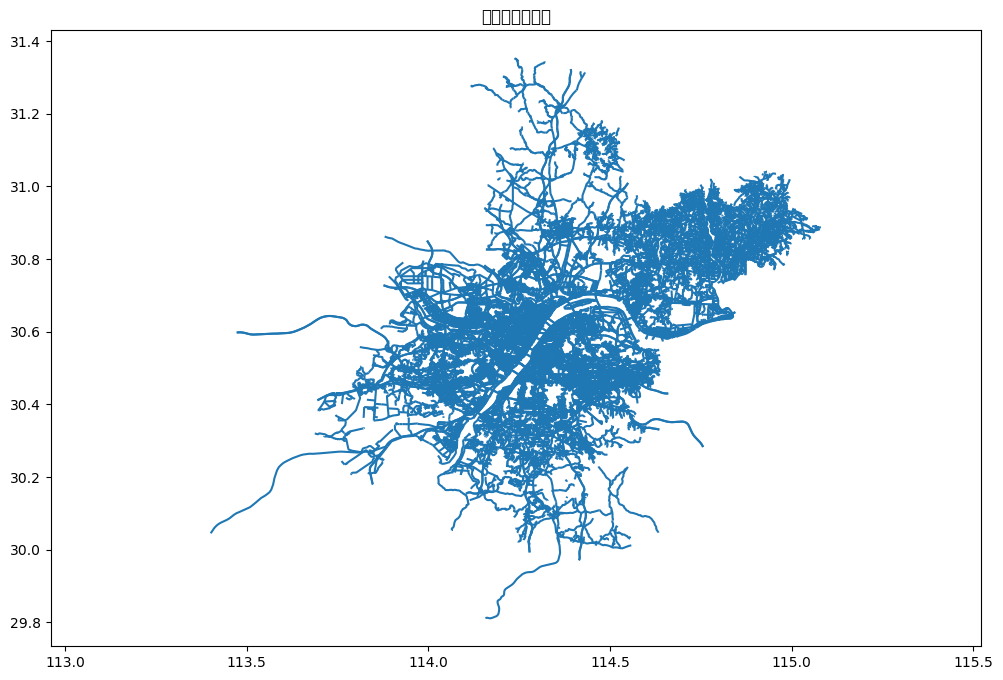

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 读取 shapefile 文件
filepath = r"F:\ScientificDatabase\Urban_Road_Network\Wuhan_China\wuhan-urn-20241126.shp"
gdf = gpd.read_file(filepath)

# 查看数据基本信息
print("数据集信息:")
print(gdf.info())

# 显示前几行数据
print("\n前5行数据:")
print(gdf.head())

# 绘制简单地图
fig, ax = plt.subplots(figsize=(12, 8))
gdf.plot(ax=ax)
plt.title('武汉市道路网络')
plt.axis('equal')
plt.show()

In [8]:
# 查看所有道路类型
print("\n所有道路类型：")
print(road_network['highway'].value_counts())


所有道路类型：
highway
unclassified      11900
residential        9595
service            7307
tertiary           4164
secondary          2852
primary            2385
motorway           1849
trunk_link         1437
trunk              1355
motorway_link      1230
primary_link        964
living_street       586
construction        518
secondary_link      434
pedestrian          239
road                162
cycleway            158
tertiary_link       147
path                100
footway              13
steps                 6
Name: count, dtype: int64


道路网络统计：
原始道路数量: 47403
筛选后道路数量: 10946

各类型道路数量：
highway
tertiary          4164
secondary         2852
primary           2385
primary_link       964
secondary_link     434
tertiary_link      147
Name: count, dtype: int64

各类型道路总长度（公里）：
highway
primary           0.024378
primary_link      0.001556
secondary         0.027579
secondary_link    0.000496
tertiary          0.039711
tertiary_link     0.000177
Name: geometry, dtype: float64


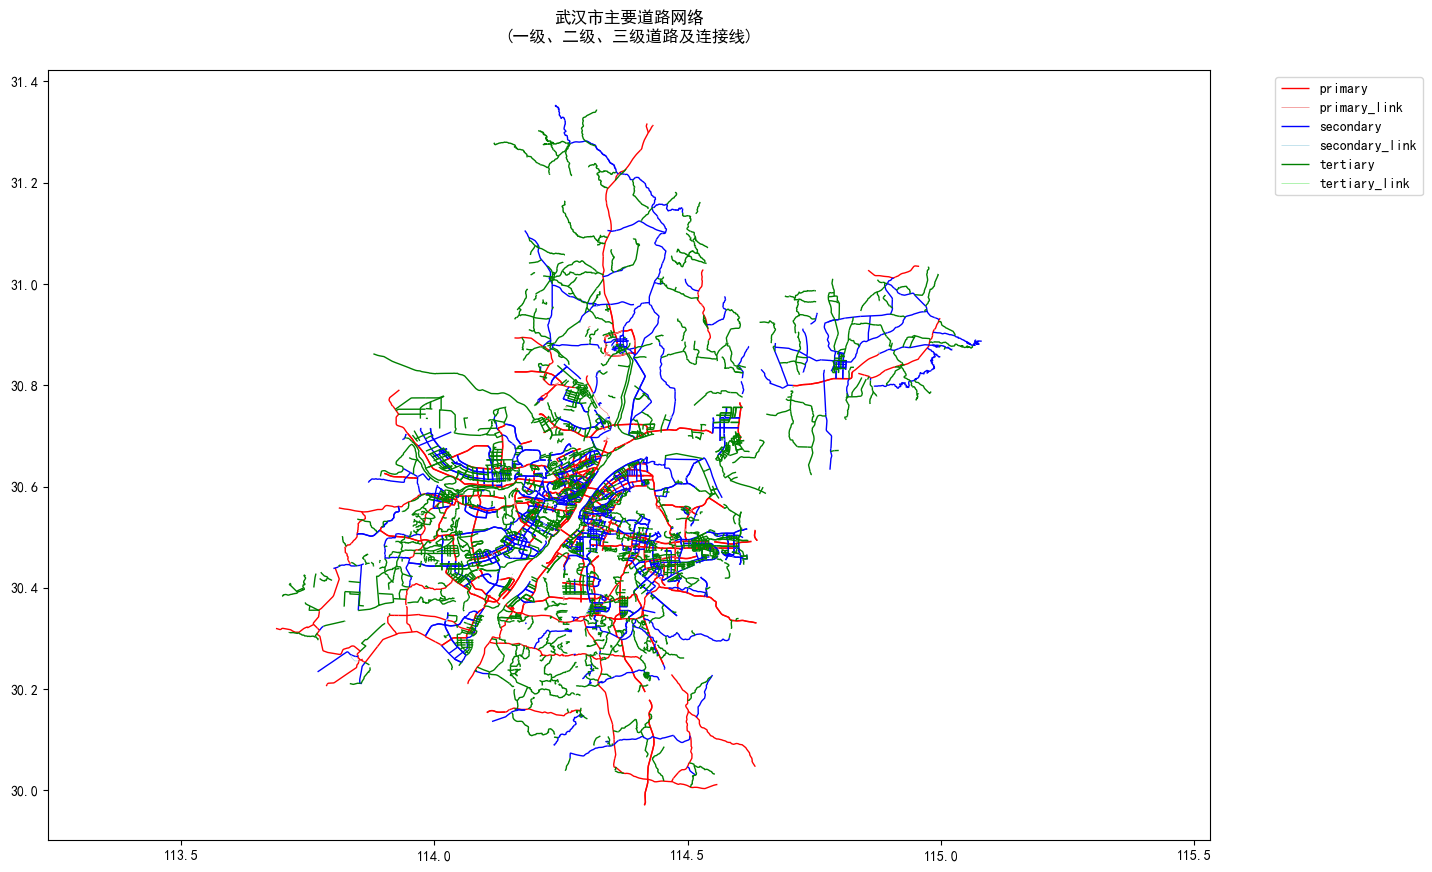


各类型道路长度占比：
primary: 25.96%
primary_link: 1.66%
secondary: 29.37%
secondary_link: 0.53%
tertiary: 42.29%
tertiary_link: 0.19%


In [9]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取道路网络数据
road_network = gpd.read_file(r"F:\ScientificDatabase\Urban_Road_Network\Wuhan_China\wuhan-urn-20241126.shp")

# 定义要筛选的道路类型
road_types = [
    'primary', 'primary_link',      # 一级道路及连接线
    'secondary', 'secondary_link',   # 二级道路及连接线
    'tertiary', 'tertiary_link'     # 三级道路及连接线
]

# 筛选道路
filtered_roads = road_network[road_network['highway'].isin(road_types)]

# 输出统计信息
print("道路网络统计：")
print(f"原始道路数量: {len(road_network)}")
print(f"筛选后道路数量: {len(filtered_roads)}")
print("\n各类型道路数量：")
road_counts = filtered_roads['highway'].value_counts()
print(road_counts)

# 计算各类型道路总长度（单位：公里）
road_lengths = filtered_roads.groupby('highway')['geometry'].apply(lambda x: sum(line.length for line in x) / 1000)
print("\n各类型道路总长度（公里）：")
print(road_lengths)

# 创建分类显示的地图
fig, ax = plt.subplots(figsize=(15, 10))

# 为不同等级道路设置不同颜色
colors = {
    'primary': 'red',
    'primary_link': 'lightcoral',
    'secondary': 'blue',
    'secondary_link': 'lightblue',
    'tertiary': 'green',
    'tertiary_link': 'lightgreen'
}

# 分类绘制道路
for road_type, color in colors.items():
    mask = filtered_roads['highway'] == road_type
    filtered_roads[mask].plot(
        ax=ax,
        color=color,
        label=road_type,
        linewidth=1 if 'link' not in road_type else 0.5
    )

plt.title('武汉市主要道路网络\n(一级、二级、三级道路及连接线)', pad=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axis('equal')

# 保存图片
plt.savefig('wuhan_main_roads.png', dpi=300, bbox_inches='tight')
plt.show()

# 保存筛选后的数据（可选）
filtered_roads.to_file("wuhan_main_roads.shp")

# 输出各等级道路的比例
total_length = road_lengths.sum()
print("\n各类型道路长度占比：")
for road_type in road_lengths.index:
    percentage = (road_lengths[road_type] / total_length) * 100
    print(f"{road_type}: {percentage:.2f}%")

正在识别交叉口...
识别出的交叉口数量: 2150
创建网格...
计算交叉口密度...


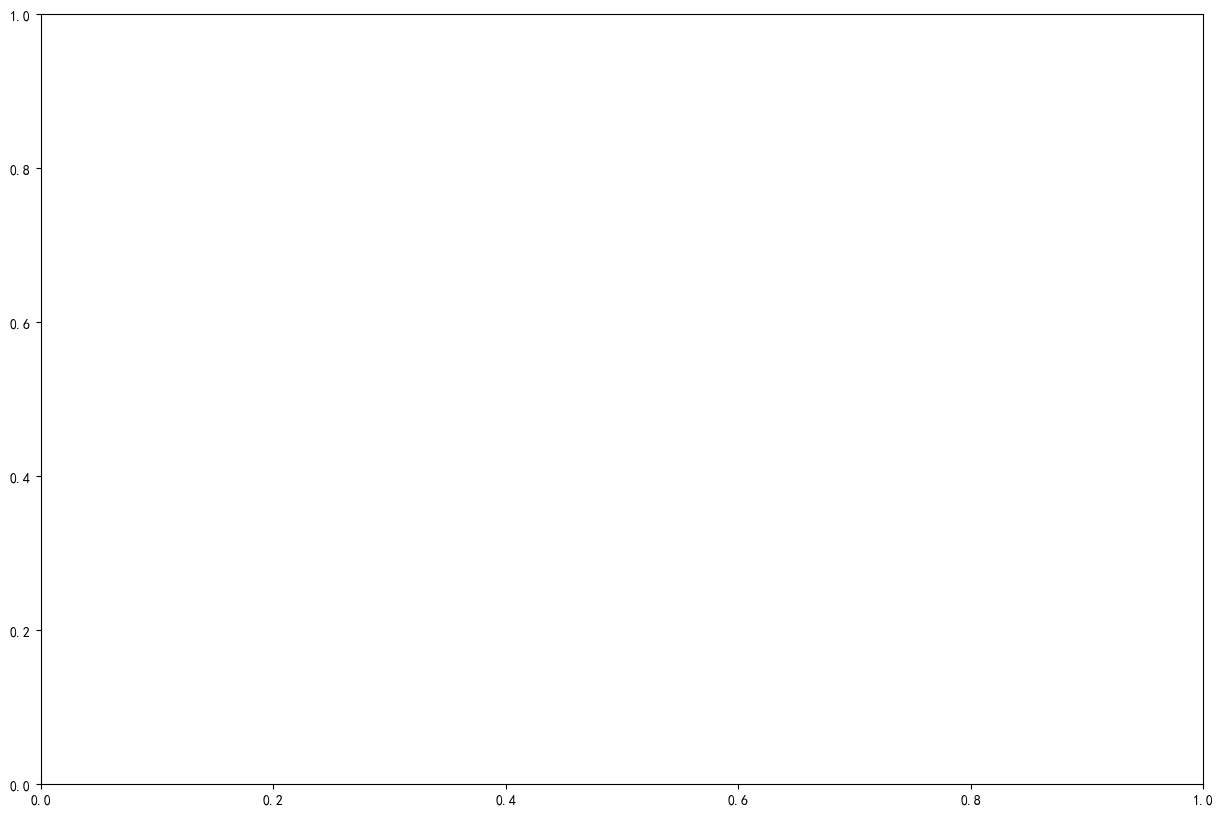

In [11]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

def identify_intersections(roads_gdf):
    """识别道路交叉口"""
    # 将所有线条转换为起点和终点
    points = []
    for line in roads_gdf.geometry:
        coords = list(line.coords)
        points.extend([Point(coord) for coord in coords])
    
    # 计算点的出现次数
    point_coords = [(p.x, p.y) for p in points]
    point_counts = pd.Series(point_coords).value_counts()
    
    # 筛选出现3次及以上的点作为交叉口
    intersections = [Point(coord) for coord in point_counts[point_counts >= 3].index]
    return gpd.GeoDataFrame({'geometry': intersections}, crs=roads_gdf.crs)

def create_grid(bounds, cell_size=1000):
    """创建网格"""
    x_min, y_min, x_max, y_max = bounds
    rows = int(np.ceil((y_max - y_min) / cell_size))
    cols = int(np.ceil((x_max - x_min) / cell_size))
    
    grid_cells = []
    for i in range(cols):
        for j in range(rows):
            x1 = x_min + i * cell_size
            y1 = y_min + j * cell_size
            x2 = x1 + cell_size
            y2 = y1 + cell_size
            grid_cells.append(Polygon([(x1,y1), (x2,y1), (x2,y2), (x1,y2)]))
    
    return gpd.GeoDataFrame({'geometry': grid_cells}, crs=filtered_roads.crs)

# 读取并筛选道路数据
road_network = gpd.read_file(r"F:\ScientificDatabase\Urban_Road_Network\Wuhan_China\wuhan-urn-20241126.shp")
road_types = ['primary', 'primary_link', 'secondary', 'secondary_link', 'tertiary', 'tertiary_link']
filtered_roads = road_network[road_network['highway'].isin(road_types)]

# 识别交叉口
print("正在识别交叉口...")
intersections = identify_intersections(filtered_roads)
print(f"识别出的交叉口数量: {len(intersections)}")

# 创建1km×1km网格
print("创建网格...")
grid = create_grid(filtered_roads.total_bounds)

# 计算每个网格的交叉口密度
print("计算交叉口密度...")
intersection_density = []
for cell in grid.geometry:
    points_in_cell = intersections[intersections.within(cell)]
    density = len(points_in_cell) / 1.0  # 每平方公里的交叉口数量
    intersection_density.append(density)

grid['intersection_density'] = intersection_density

# 创建可视化图
fig, ax = plt.subplots(figsize=(15, 10))

# # 绘制密度热力图
# grid.plot(column='intersection_density', 
#          ax=ax,
#          legend=True,
#          cmap='YlOrRd',
#          legend_kwds={'label': '交叉口密度 (个/km²)'})

# # 添加道路网络和交叉口
# filtered_roads.plot(ax=ax, color='black', linewidth=0.1, alpha=0.3)
# intersections.plot(ax=ax, color='blue', markersize=1, alpha=0.5)

# plt.title('武汉市主要道路交叉口密度分布\n(基于一、二、三级道路)', fontsize=14, pad=20)
# plt.axis('equal')

# # 保存结果
# plt.savefig('wuhan_main_roads_intersection_density.png', dpi=300, bbox_inches='tight')
# plt.show()

# # 输出统计信息
# total_area = len(grid)  # 总网格数即总面积(km²)
# total_intersections = len(intersections)
# mean_density = grid['intersection_density'].mean()
# max_density = grid['intersection_density'].max()

# print("\n交叉口密度统计信息：")
# print(f"研究区域面积: {total_area:.2f} km²")
# print(f"总交叉口数量: {total_intersections}")
# print(f"平均交叉口密度: {mean_density:.2f} 个/km²")
# print(f"最大交叉口密度: {max_density:.2f} 个/km²")

# # 计算分位数统计
# percentiles = [0, 25, 50, 75, 100]
# density_stats = np.percentile(grid['intersection_density'], percentiles)
# print("\n交叉口密度分布情况：")
# for p, v in zip(percentiles, density_stats):
#     print(f"{p}分位数: {v:.2f} 个/km²")

# # 保存数据
# grid.to_file("wuhan_main_roads_intersection_density.shp")
# intersections.to_file("wuhan_main_roads_intersections.shp")

正在识别交叉口...
识别出的交叉口数量: 2150

交叉口统计信息：
总交叉口数量: 2150


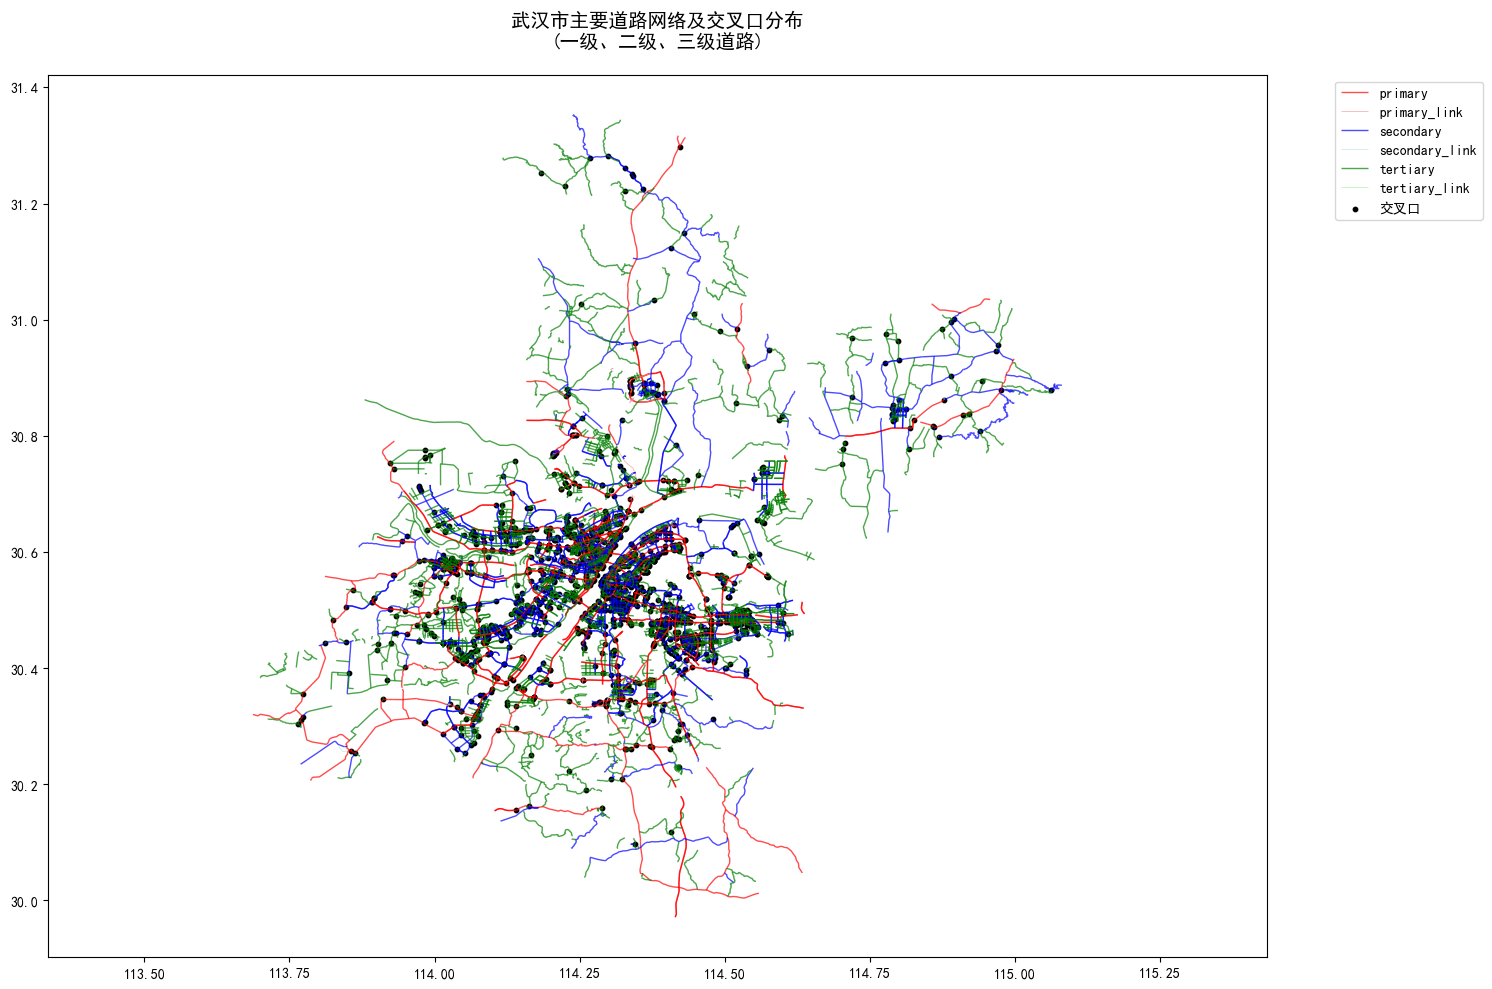


道路网络总长度: 0.09 km
平均交叉口密度: 22897.72 个/km

primary:
道路长度: 0.02 km
占总长度比例: 25.96%

primary_link:
道路长度: 0.00 km
占总长度比例: 1.66%

secondary:
道路长度: 0.03 km
占总长度比例: 29.37%

secondary_link:
道路长度: 0.00 km
占总长度比例: 0.53%

tertiary:
道路长度: 0.04 km
占总长度比例: 42.29%

tertiary_link:
道路长度: 0.00 km
占总长度比例: 0.19%


C:\Users\asus\AppData\Local\Temp\ipykernel_27172\2241264109.py:73: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  total_length = filtered_roads.geometry.length.sum() / 1000  # 转换为公里
C:\Users\asus\AppData\Local\Temp\ipykernel_27172\2241264109.py:82: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  length = roads.geometry.length.sum() / 1000
C:\Users\asus\AppData\Local\Temp\ipykernel_27172\2241264109.py:82: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  length = roads.geometry.length.sum() / 1000
C:\Users\asus\AppData\Local\Temp\ipykernel_27172\2241264109.py:82: UserWarning: Geometry

In [12]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取和筛选道路数据
road_network = gpd.read_file(r"F:\ScientificDatabase\Urban_Road_Network\Wuhan_China\wuhan-urn-20241126.shp")
road_types = ['primary', 'primary_link', 'secondary', 'secondary_link', 'tertiary', 'tertiary_link']
filtered_roads = road_network[road_network['highway'].isin(road_types)]

def identify_intersections(roads_gdf):
    """识别道路交叉口"""
    points = []
    for line in roads_gdf.geometry:
        coords = list(line.coords)
        points.extend([Point(coord) for coord in coords])
    
    point_coords = [(p.x, p.y) for p in points]
    point_counts = pd.Series(point_coords).value_counts()
    
    intersections = [Point(coord) for coord in point_counts[point_counts >= 3].index]
    return gpd.GeoDataFrame({'geometry': intersections}, crs=roads_gdf.crs)

# 识别交叉口
print("正在识别交叉口...")
intersections = identify_intersections(filtered_roads)
print(f"识别出的交叉口数量: {len(intersections)}")

# 创建可视化图
fig, ax = plt.subplots(figsize=(15, 10))

# 为不同等级道路设置不同颜色
colors = {
    'primary': 'red',
    'primary_link': 'lightcoral',
    'secondary': 'blue',
    'secondary_link': 'lightblue',
    'tertiary': 'green',
    'tertiary_link': 'lightgreen'
}

# 分类绘制道路
for road_type, color in colors.items():
    mask = filtered_roads['highway'] == road_type
    filtered_roads[mask].plot(
        ax=ax,
        color=color,
        label=road_type,
        linewidth=1 if 'link' not in road_type else 0.5,
        alpha=0.7
    )

# 添加交叉口
intersections.plot(ax=ax, color='black', marker='o', markersize=10, label='交叉口')

# 设置标题和图例
plt.title('武汉市主要道路网络及交叉口分布\n(一级、二级、三级道路)', fontsize=14, pad=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axis('equal')

# 输出统计信息
print("\n交叉口统计信息：")
print(f"总交叉口数量: {len(intersections)}")

# 显示图形
plt.tight_layout()
plt.show()

# 计算每类道路的长度和交叉口密度
total_length = filtered_roads.geometry.length.sum() / 1000  # 转换为公里
intersection_density = len(intersections) / total_length

print(f"\n道路网络总长度: {total_length:.2f} km")
print(f"平均交叉口密度: {intersection_density:.2f} 个/km")

# 按道路类型统计
for road_type in road_types:
    roads = filtered_roads[filtered_roads['highway'] == road_type]
    length = roads.geometry.length.sum() / 1000
    print(f"\n{road_type}:")
    print(f"道路长度: {length:.2f} km")
    print(f"占总长度比例: {(length/total_length*100):.2f}%")

转换为投影坐标系...
创建1km×1km网格...


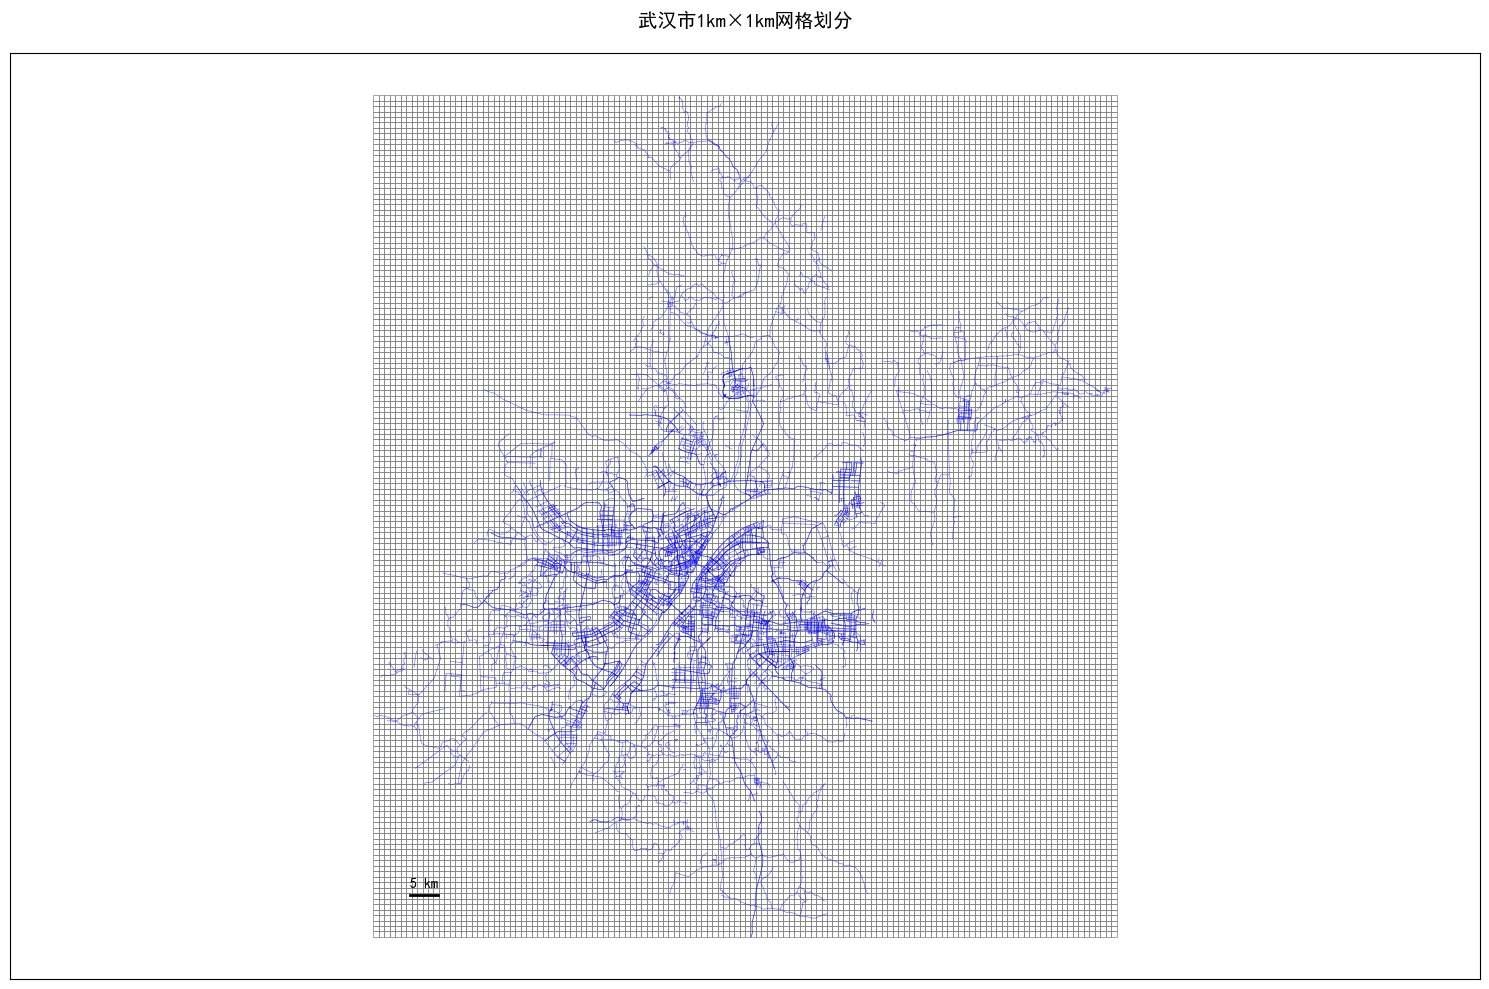


网格统计信息：
总网格数量: 20944
研究区域范围（米）:
东西方向: 135133米
南北方向: 153671米
总面积: 20766.06平方公里


In [21]:
# import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

def create_grid(bounds, cell_size=1000):
    """创建1km×1km网格"""
    x_min, y_min, x_max, y_max = bounds
    
    # 创建网格
    x_coords = np.arange(x_min, x_max + cell_size, cell_size)
    y_coords = np.arange(y_min, y_max + cell_size, cell_size)
    
    grid_cells = []
    grid_ids = []
    id_number = 0
    
    for x in x_coords[:-1]:
        for y in y_coords[:-1]:
            cell = Polygon([
                (x, y),
                (x + cell_size, y),
                (x + cell_size, y + cell_size),
                (x, y + cell_size)
            ])
            grid_cells.append(cell)
            grid_ids.append(id_number)
            id_number += 1
    
    return gpd.GeoDataFrame({
        'grid_id': grid_ids,
        'geometry': grid_cells
    })

# 读取道路网络数据
road_network = gpd.read_file(r"F:\ScientificDatabase\Urban_Road_Network\Wuhan_China\wuhan-urn-20241126.shp")

# 确保使用投影坐标系
if not road_network.crs.is_projected:
    print("转换为投影坐标系...")
    road_network = road_network.to_crs('EPSG:32650')  # WGS 84 / UTM zone 50N

# 筛选道路
road_types = ['primary', 'primary_link', 'secondary', 'secondary_link', 'tertiary', 'tertiary_link']
filtered_roads = road_network[road_network['highway'].isin(road_types)]

# 创建网格
print("创建1km×1km网格...")
grid = create_grid(filtered_roads.total_bounds)
grid.crs = filtered_roads.crs  # 设置与道路数据相同的坐标系

# 创建可视化图
fig, ax = plt.subplots(figsize=(15, 10))

# 绘制网格线
grid.boundary.plot(ax=ax, color='gray', linewidth=0.5)

# 绘制道路网络
filtered_roads.plot(ax=ax, color='blue', linewidth=0.5, alpha=0.5)

# 设置标题
plt.title('武汉市1km×1km网格划分', fontsize=14, pad=20)

# 添加比例尺
extent = filtered_roads.total_bounds
scale_bar_length = 5000  # 5公里
scale_bar_x = extent[0] + (extent[2] - extent[0]) * 0.05
scale_bar_y = extent[1] + (extent[3] - extent[1]) * 0.05
plt.plot([scale_bar_x, scale_bar_x + scale_bar_length], 
         [scale_bar_y, scale_bar_y], 
         'k-', linewidth=2)
plt.text(scale_bar_x + scale_bar_length/2, 
         scale_bar_y + (extent[3] - extent[1]) * 0.01, 
         '5 km', 
         ha='center')

# 设置坐标轴
plt.axis('equal')
ax.set_xticks([])
ax.set_yticks([])

# 显示图形
plt.tight_layout()
plt.show()

# 输出网格统计信息
print(f"\n网格统计信息：")
print(f"总网格数量: {len(grid)}")
extent = filtered_roads.total_bounds
print(f"研究区域范围（米）:")
print(f"东西方向: {extent[2] - extent[0]:.0f}米")
print(f"南北方向: {extent[3] - extent[1]:.0f}米")
print(f"总面积: {(extent[2] - extent[0]) * (extent[3] - extent[1]) / 1000000:.2f}平方公里")

转换为投影坐标系...
识别交叉口...
识别出的交叉口数量: 2150
创建1km×1km网格...
计算网格交叉口数量...


C:\Users\asus\AppData\Roaming\Python\Python311\site-packages\geopandas\plotting.py:956: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  ax.figure.canvas.draw_idle()
C:\Users\asus\AppData\Roaming\Python\Python311\site-packages\geopandas\plotting.py:482: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  ax.figure.canvas.draw_idle()
c:\Users\asus\.conda\envs\pytorch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


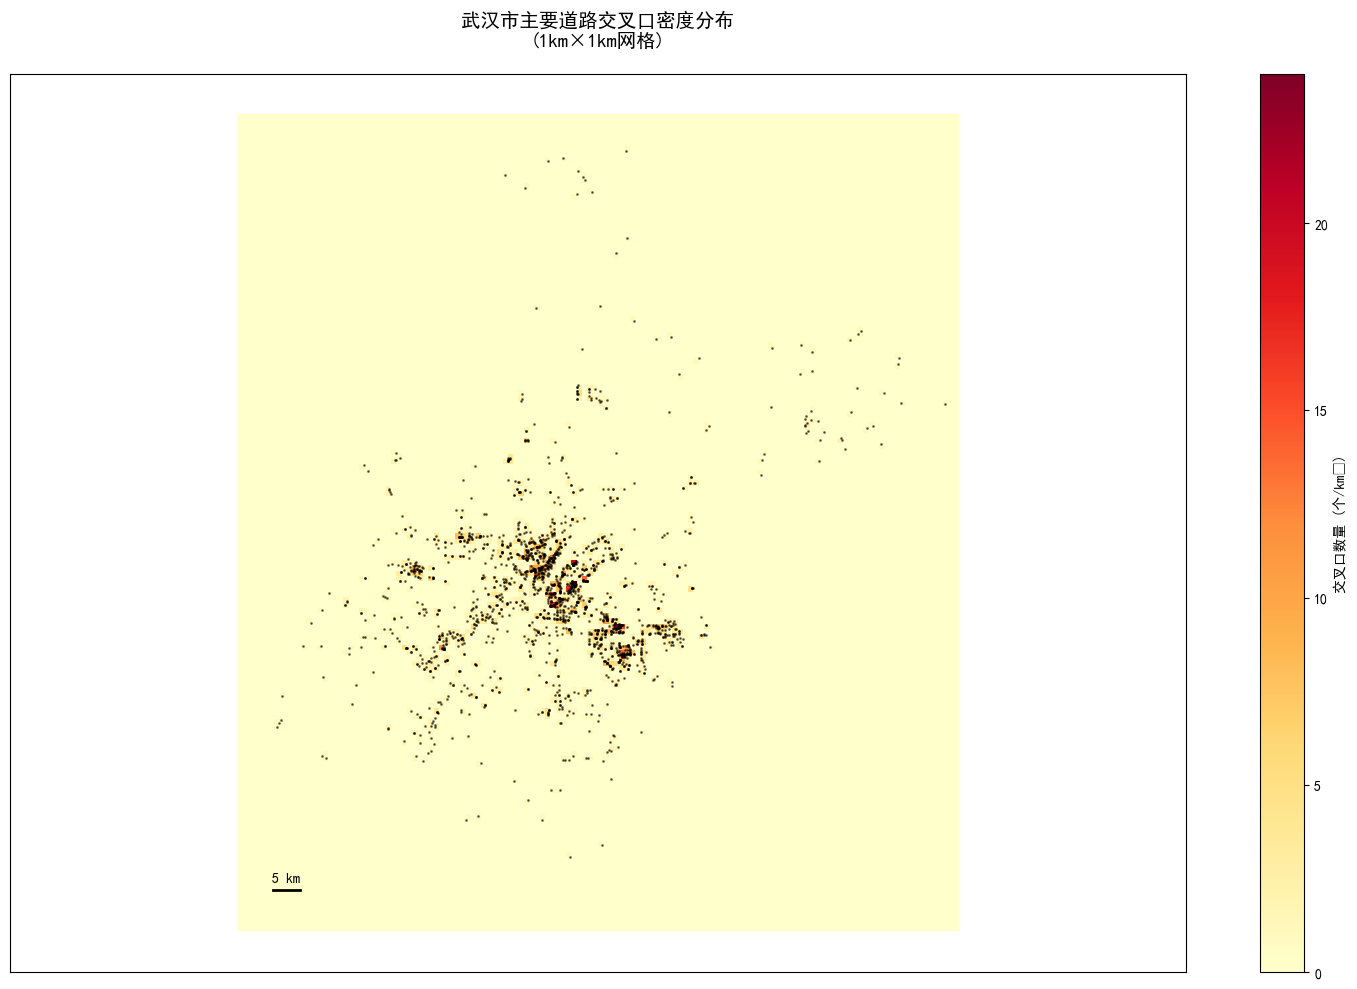


交叉口密度统计：
总网格数: 20944
总交叉口数: 2150
平均每网格交叉口数: 0.10
最大网格交叉口数: 24
有交叉口的网格数: 848

交叉口数量分布（分位数）：
0分位数: 0.00
25分位数: 0.00
50分位数: 0.00
75分位数: 0.00
100分位数: 24.00


In [22]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

def identify_intersections(roads_gdf):
    """识别道路交叉口"""
    points = []
    for line in roads_gdf.geometry:
        coords = list(line.coords)
        points.extend([Point(coord) for coord in coords])
    
    point_coords = [(p.x, p.y) for p in points]
    point_counts = pd.Series(point_coords).value_counts()
    
    # 筛选出现3次及以上的点作为交叉口
    intersections = [Point(coord) for coord in point_counts[point_counts >= 3].index]
    return gpd.GeoDataFrame({'geometry': intersections}, crs=roads_gdf.crs)

def create_grid(bounds, cell_size=1000):
    """创建1km×1km网格"""
    x_min, y_min, x_max, y_max = bounds
    x_coords = np.arange(x_min, x_max + cell_size, cell_size)
    y_coords = np.arange(y_min, y_max + cell_size, cell_size)
    
    grid_cells = []
    grid_ids = []
    id_number = 0
    
    for x in x_coords[:-1]:
        for y in y_coords[:-1]:
            cell = Polygon([
                (x, y),
                (x + cell_size, y),
                (x + cell_size, y + cell_size),
                (x, y + cell_size)
            ])
            grid_cells.append(cell)
            grid_ids.append(id_number)
            id_number += 1
    
    return gpd.GeoDataFrame({
        'grid_id': grid_ids,
        'geometry': grid_cells
    })

# 读取和处理数据
road_network = gpd.read_file(r"F:\ScientificDatabase\Urban_Road_Network\Wuhan_China\wuhan-urn-20241126.shp")

# 确保使用投影坐标系
if not road_network.crs.is_projected:
    print("转换为投影坐标系...")
    road_network = road_network.to_crs('EPSG:32650')

# 筛选道路
road_types = ['primary', 'primary_link', 'secondary', 'secondary_link', 'tertiary', 'tertiary_link']
filtered_roads = road_network[road_network['highway'].isin(road_types)]

# 识别交叉口
print("识别交叉口...")
intersections = identify_intersections(filtered_roads)
print(f"识别出的交叉口数量: {len(intersections)}")

# 创建网格
print("创建1km×1km网格...")
grid = create_grid(filtered_roads.total_bounds)
grid.crs = filtered_roads.crs

# 计算每个网格中的交叉口数量
print("计算网格交叉口数量...")
intersection_counts = []
for cell in grid.geometry:
    points_in_cell = sum(1 for point in intersections.geometry if point.within(cell))
    intersection_counts.append(points_in_cell)

grid['intersection_count'] = intersection_counts

# 创建可视化图
fig, ax = plt.subplots(figsize=(15, 10))

# 绘制密度热力图
grid.plot(column='intersection_count', 
         ax=ax,
         legend=True,
         cmap='YlOrRd',
         legend_kwds={'label': '交叉口数量 (个/km²)'})

# 添加交叉口点
intersections.plot(ax=ax, color='black', markersize=1, alpha=0.5)

# 设置标题
plt.title('武汉市主要道路交叉口密度分布\n(1km×1km网格)', fontsize=14, pad=20)

# 添加比例尺
extent = filtered_roads.total_bounds
scale_bar_length = 5000  # 5公里
scale_bar_x = extent[0] + (extent[2] - extent[0]) * 0.05
scale_bar_y = extent[1] + (extent[3] - extent[1]) * 0.05
plt.plot([scale_bar_x, scale_bar_x + scale_bar_length], 
         [scale_bar_y, scale_bar_y], 
         'k-', linewidth=2)
plt.text(scale_bar_x + scale_bar_length/2, 
         scale_bar_y + (extent[3] - extent[1]) * 0.01, 
         '5 km', 
         ha='center')

# 设置坐标轴
plt.axis('equal')
ax.set_xticks([])
ax.set_yticks([])

# 显示图形
plt.tight_layout()
plt.show()

# 输出统计信息
print("\n交叉口密度统计：")
print(f"总网格数: {len(grid)}")
print(f"总交叉口数: {len(intersections)}")
print(f"平均每网格交叉口数: {grid['intersection_count'].mean():.2f}")
print(f"最大网格交叉口数: {grid['intersection_count'].max()}")
print(f"有交叉口的网格数: {sum(grid['intersection_count'] > 0)}")

# 计算分位数统计
percentiles = [0, 25, 50, 75, 100]
density_stats = np.percentile(grid['intersection_count'], percentiles)
print("\n交叉口数量分布（分位数）：")
for p, v in zip(percentiles, density_stats):
    print(f"{p}分位数: {v:.2f}")

转换为投影坐标系...
识别交叉口...
识别出的交叉口数量: 2150
创建5km×5km网格...
计算网格交叉口数量...


C:\Users\asus\AppData\Roaming\Python\Python311\site-packages\geopandas\plotting.py:956: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  ax.figure.canvas.draw_idle()
C:\Users\asus\AppData\Roaming\Python\Python311\site-packages\geopandas\plotting.py:482: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  ax.figure.canvas.draw_idle()
c:\Users\asus\.conda\envs\pytorch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


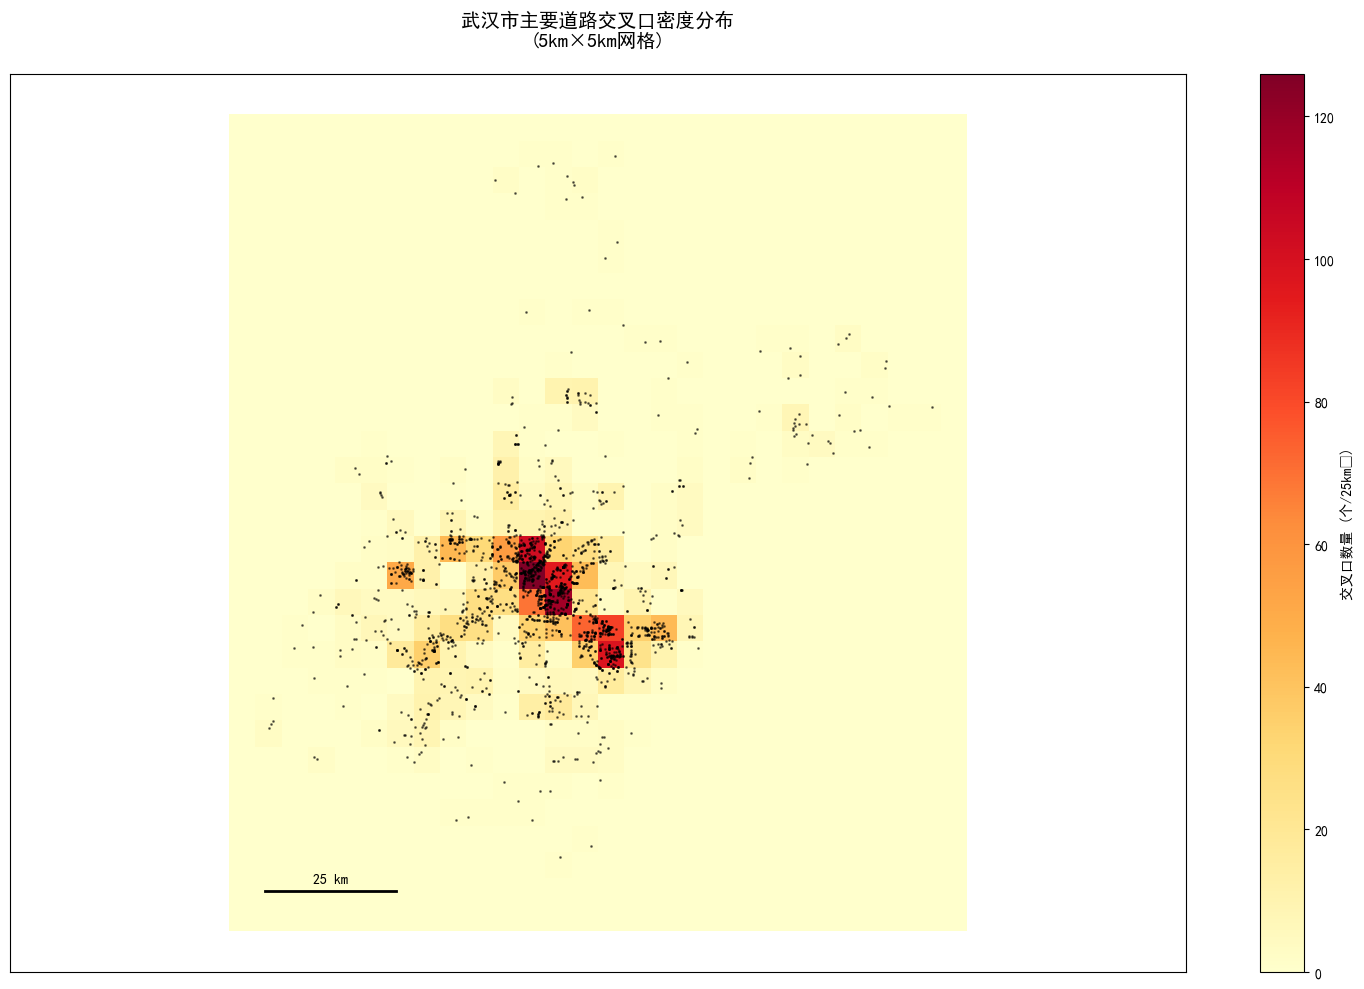


交叉口密度统计（5km×5km网格）：
总网格数: 868
总交叉口数: 2150
平均每网格交叉口数: 2.48
最大网格交叉口数: 126
有交叉口的网格数: 196
每网格面积: 25 km²

交叉口密度统计（个/km²）：
平均密度: 0.10
最大密度: 5.04

交叉口密度分布（个/km²）：
0分位数: 0.00
25分位数: 0.00
50分位数: 0.00
75分位数: 0.00
100分位数: 5.04


In [24]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

def identify_intersections(roads_gdf):
    """识别道路交叉口"""
    points = []
    for line in roads_gdf.geometry:
        coords = list(line.coords)
        points.extend([Point(coord) for coord in coords])
    
    point_coords = [(p.x, p.y) for p in points]
    point_counts = pd.Series(point_coords).value_counts()
    
    intersections = [Point(coord) for coord in point_counts[point_counts >= 3].index]
    return gpd.GeoDataFrame({'geometry': intersections}, crs=roads_gdf.crs)

def create_grid(bounds, cell_size=5000):
    """创建5km×5km网格"""
    x_min, y_min, x_max, y_max = bounds
    x_coords = np.arange(x_min, x_max + cell_size, cell_size)
    y_coords = np.arange(y_min, y_max + cell_size, cell_size)
    
    grid_cells = []
    grid_ids = []
    id_number = 0
    
    for x in x_coords[:-1]:
        for y in y_coords[:-1]:
            cell = Polygon([
                (x, y),
                (x + cell_size, y),
                (x + cell_size, y + cell_size),
                (x, y + cell_size)
            ])
            grid_cells.append(cell)
            grid_ids.append(id_number)
            id_number += 1
    
    return gpd.GeoDataFrame({
        'grid_id': grid_ids,
        'geometry': grid_cells
    })

# 读取和处理数据
road_network = gpd.read_file(r"F:\ScientificDatabase\Urban_Road_Network\Wuhan_China\wuhan-urn-20241126.shp")

# 确保使用投影坐标系
if not road_network.crs.is_projected:
    print("转换为投影坐标系...")
    road_network = road_network.to_crs('EPSG:32650')

# 筛选道路
road_types = ['primary', 'primary_link', 'secondary', 'secondary_link', 'tertiary', 'tertiary_link']
filtered_roads = road_network[road_network['highway'].isin(road_types)]

# 识别交叉口
print("识别交叉口...")
intersections = identify_intersections(filtered_roads)
print(f"识别出的交叉口数量: {len(intersections)}")

# 创建网格
print("创建5km×5km网格...")
grid = create_grid(filtered_roads.total_bounds)
grid.crs = filtered_roads.crs

# 计算每个网格中的交叉口数量
print("计算网格交叉口数量...")
intersection_counts = []
for cell in grid.geometry:
    points_in_cell = sum(1 for point in intersections.geometry if point.within(cell))
    intersection_counts.append(points_in_cell)

grid['intersection_count'] = intersection_counts
grid['density_per_km2'] = grid['intersection_count'] / 25  # 每平方公里的交叉口密度

# 创建可视化图
fig, ax = plt.subplots(figsize=(15, 10))

# 绘制密度热力图
grid.plot(column='intersection_count', 
         ax=ax,
         legend=True,
         cmap='YlOrRd',
         legend_kwds={'label': '交叉口数量 (个/25km²)'})

# 添加交叉口点
intersections.plot(ax=ax, color='black', markersize=1, alpha=0.5)

# 设置标题
plt.title('武汉市主要道路交叉口密度分布\n(5km×5km网格)', fontsize=14, pad=20)

# 添加比例尺
extent = filtered_roads.total_bounds
scale_bar_length = 25000  # 25公里
scale_bar_x = extent[0] + (extent[2] - extent[0]) * 0.05
scale_bar_y = extent[1] + (extent[3] - extent[1]) * 0.05
plt.plot([scale_bar_x, scale_bar_x + scale_bar_length], 
         [scale_bar_y, scale_bar_y], 
         'k-', linewidth=2)
plt.text(scale_bar_x + scale_bar_length/2, 
         scale_bar_y + (extent[3] - extent[1]) * 0.01, 
         '25 km', 
         ha='center')

# 设置坐标轴
plt.axis('equal')
ax.set_xticks([])
ax.set_yticks([])

# 显示图形
plt.tight_layout()
plt.show()

# 输出统计信息
print("\n交叉口密度统计（5km×5km网格）：")
print(f"总网格数: {len(grid)}")
print(f"总交叉口数: {len(intersections)}")
print(f"平均每网格交叉口数: {grid['intersection_count'].mean():.2f}")
print(f"最大网格交叉口数: {grid['intersection_count'].max()}")
print(f"有交叉口的网格数: {sum(grid['intersection_count'] > 0)}")
print(f"每网格面积: 25 km²")

print("\n交叉口密度统计（个/km²）：")
print(f"平均密度: {grid['density_per_km2'].mean():.2f}")
print(f"最大密度: {grid['density_per_km2'].max():.2f}")

# 计算分位数统计
percentiles = [0, 25, 50, 75, 100]
density_stats = np.percentile(grid['density_per_km2'], percentiles)
print("\n交叉口密度分布（个/km²）：")
for p, v in zip(percentiles, density_stats):
    print(f"{p}分位数: {v:.2f}")